# Notebook 02: Near-Duplicate Audit and Reproducible Data Splits

This notebook:

1. Reviews cross-split perceptual-hash near-duplicate candidates.
2. Excludes only confirmed cross-split leakage cases.
3. Creates a reproducible 85/15 train/calibration split from the original training partition.
4. Locks the cleaned original validation partition as the untouched internal test set.
5. Exports separate manifests for:
   - Main 19-class disease classification task
   - Auxiliary 20-class classification task including healthy soybean

In [57]:
!pip install -q imagehash scikit-learn

import os
import json
import random
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 7

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [58]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "split_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MANIFEST_DIR = OUTPUT_DIR / "manifests"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MANIFEST_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PLANTVILLAGE_ROOT = Path(
    "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage"
)

assert PLANTVILLAGE_ROOT.exists(), (
    f"PlantVillage root not found:\n{PLANTVILLAGE_ROOT}"
)

print("PlantVillage root:")
print(PLANTVILLAGE_ROOT)

print("\nOutput directory:")
print(OUTPUT_DIR)

PlantVillage root:
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage

Output directory:
/kaggle/working/split_outputs


In [59]:
def find_file_under_kaggle_input(file_name):
    matches = list(INPUT_ROOT.rglob(file_name))
    
    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not locate '{file_name}' under /kaggle/input.\n"
            "Attach the output dataset from Notebook 01 to this notebook."
        )
    
    return matches[0]


CLEAN_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/plantvillage_selected_manifest_clean.csv"

NEAR_DUPLICATE_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/Eda-tables/Eda-tables/near_duplicate_candidates_phash_hamming_le4.csv"

print("Clean manifest:")
print(CLEAN_MANIFEST_PATH)

print("\nNear-duplicate candidates:")
print(NEAR_DUPLICATE_PATH)

Clean manifest:
/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/plantvillage_selected_manifest_clean.csv

Near-duplicate candidates:
/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/Eda-tables/Eda-tables/near_duplicate_candidates_phash_hamming_le4.csv


In [60]:
master_df = pd.read_csv(CLEAN_MANIFEST_PATH)
near_df = pd.read_csv(NEAR_DUPLICATE_PATH)

print("Raw manifest shape:", master_df.shape)
print("Near-duplicate candidate shape:", near_df.shape)

# Remove the five validation samples that the SHA-256 audit flagged
# as byte-identical copies of training images.
if "exclude_from_evaluation" in master_df.columns:
    exact_duplicate_mask = (
        master_df["exclude_from_evaluation"]
        .fillna(0)
        .astype(int)
        .eq(1)
    )

    exact_duplicate_count = int(exact_duplicate_mask.sum())
    master_df = master_df.loc[~exact_duplicate_mask].copy()
else:
    exact_duplicate_count = 0

print("\nExact-duplicate validation records excluded:", exact_duplicate_count)
print("Active master manifest shape:", master_df.shape)

required_master_columns = {
    "image_path",
    "split",
    "crop",
    "disease",
    "label",
    "is_healthy",
    "sha256",
    "phash",
    "is_corrupt"
}

missing_master = required_master_columns - set(master_df.columns)

assert not missing_master, (
    f"Missing required columns: {missing_master}"
)

assert len(master_df) == 31724, (
    f"Expected 31,724 retained images, found {len(master_df)}."
)

assert master_df["split"].isin(["train", "val"]).all()
assert master_df["is_corrupt"].sum() == 0
assert master_df["label"].nunique() == 20

print("\nValidation passed.")
print("Clean images:", len(master_df))
print("Classes:", master_df["label"].nunique())
print("Train images:", (master_df["split"] == "train").sum())
print("Held-out images:", (master_df["split"] == "val").sum())

Raw manifest shape: (31729, 18)
Near-duplicate candidate shape: (136, 8)

Exact-duplicate validation records excluded: 5
Active master manifest shape: (31724, 18)

Validation passed.
Clean images: 31724
Classes: 20
Train images: 25382
Held-out images: 6342


In [61]:
display(near_df.head())

print("\nCandidate count:", len(near_df))

print("\nCandidate distance distribution:")
distance_columns = [
    col for col in near_df.columns
    if "distance" in col.lower() or "hamming" in col.lower()
]

print(distance_columns)

if distance_columns:
    display(
        near_df[distance_columns]
        .describe()
        .T
    )

,label,hamming_distance,train_image_path,train_file_name,train_phash,val_image_path,val_file_name,val_phash
0,corn__healthy,0,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Corn_(maize)___healthy/94ca39a0-d4df-44c6-b5cc...,94ca39a0-d4df-44c6-b5cc-a38a754506e5___R.S_HL 0601 copy 3.jpg,8080a02b9abb6fff,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Corn_(maize)___healthy/8afc9635-c5e3-41be-aac0-7...,8afc9635-c5e3-41be-aac0-74109d6112ed___R.S_HL 0601 copy 2.jpg,8080a02b9abb6fff
1,potato__early_blight,2,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Potato___Early_blight/5aee3e9f-0469-42e7-8ae7-...,5aee3e9f-0469-42e7-8ae7-56f7a1900fd5___RS_Early.B 9091.JPG,8a3dbd70e0c3c48f,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Potato___Early_blight/bc378ba0-533d-42db-a8b2-82...,bc378ba0-533d-42db-a8b2-82decc73f4d5___RS_Early.B 9092.JPG,8a3dbd70f0c3c48e
2,soybean__healthy,2,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/6099a20b-61bc-40c6-9f74-9d64...,6099a20b-61bc-40c6-9f74-9d64ee57f24a___RS_HL 6070.JPG,ae35f152c14b856d,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/04bc7e4f-8fea-40cd-a4d3-4c83c8...,04bc7e4f-8fea-40cd-a4d3-4c83c823c526___RS_HL 6072.JPG,ae35f052c16b856d
3,soybean__healthy,2,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/02f3a559-6f7c-43d4-bd61-2395...,02f3a559-6f7c-43d4-bd61-23951756f43e___RS_HL 5805 1.JPG,ffa0a017975a9e28,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/66470940-d138-4a1c-8c96-0fcd0b...,66470940-d138-4a1c-8c96-0fcd0b6a6f7f___RS_HL 6346.JPG,ffa0e017875a9e28
4,soybean__healthy,2,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/23c541f5-e1f9-45a4-9e05-4a4e...,23c541f5-e1f9-45a4-9e05-4a4ed0609b60___RS_HL 4832.JPG,ffa0e017875a9e60,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/66470940-d138-4a1c-8c96-0fcd0b...,66470940-d138-4a1c-8c96-0fcd0b6a6f7f___RS_HL 6346.JPG,ffa0e017875a9e28



Candidate count: 136

Candidate distance distribution:
['hamming_distance']


,count,mean,std,min,25%,50%,75%,max
hamming_distance,136.0,3.838235,0.599019,0.0,4.0,4.0,4.0,4.0


In [62]:
# Candidate CSV columns confirmed from Notebook 01:
# label, hamming_distance, train_image_path, train_file_name,
# train_phash, val_image_path, val_file_name, val_phash

required_candidate_columns = {
    "label",
    "hamming_distance",
    "train_image_path",
    "train_file_name",
    "train_phash",
    "val_image_path",
    "val_file_name",
    "val_phash"
}

missing_candidate_columns = required_candidate_columns - set(near_df.columns)

assert not missing_candidate_columns, (
    f"Candidate CSV is missing columns: {missing_candidate_columns}"
)

review_df = pd.DataFrame({
    "candidate_id": np.arange(1, len(near_df) + 1),
    "image_a_path": near_df["train_image_path"].astype(str),
    "image_b_path": near_df["val_image_path"].astype(str),
    "phash_hamming_distance": near_df["hamming_distance"].astype(int),
    "original_label": near_df["label"].astype(str),
    "train_file_name_source": near_df["train_file_name"].astype(str),
    "val_file_name_source": near_df["val_file_name"].astype(str),
    "train_phash_source": near_df["train_phash"].astype(str),
    "val_phash_source": near_df["val_phash"].astype(str),
})

print("Candidate-pair review table created.")
print("Total cross-split candidate pairs:", len(review_df))
print("Hamming-distance range:",
      review_df["phash_hamming_distance"].min(),
      "to",
      review_df["phash_hamming_distance"].max())

display(review_df.head())

Candidate-pair review table created.
Total cross-split candidate pairs: 136
Hamming-distance range: 0 to 4


,candidate_id,image_a_path,image_b_path,phash_hamming_distance,original_label,train_file_name_source,val_file_name_source,train_phash_source,val_phash_source
0,1,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Corn_(maize)___healthy/94ca39a0-d4df-44c6-b5cc...,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Corn_(maize)___healthy/8afc9635-c5e3-41be-aac0-7...,0,corn__healthy,94ca39a0-d4df-44c6-b5cc-a38a754506e5___R.S_HL 0601 copy 3.jpg,8afc9635-c5e3-41be-aac0-74109d6112ed___R.S_HL 0601 copy 2.jpg,8080a02b9abb6fff,8080a02b9abb6fff
1,2,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Potato___Early_blight/5aee3e9f-0469-42e7-8ae7-...,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Potato___Early_blight/bc378ba0-533d-42db-a8b2-82...,2,potato__early_blight,5aee3e9f-0469-42e7-8ae7-56f7a1900fd5___RS_Early.B 9091.JPG,bc378ba0-533d-42db-a8b2-82decc73f4d5___RS_Early.B 9092.JPG,8a3dbd70e0c3c48f,8a3dbd70f0c3c48e
2,3,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/6099a20b-61bc-40c6-9f74-9d64...,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/04bc7e4f-8fea-40cd-a4d3-4c83c8...,2,soybean__healthy,6099a20b-61bc-40c6-9f74-9d64ee57f24a___RS_HL 6070.JPG,04bc7e4f-8fea-40cd-a4d3-4c83c823c526___RS_HL 6072.JPG,ae35f152c14b856d,ae35f052c16b856d
3,4,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/02f3a559-6f7c-43d4-bd61-2395...,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/66470940-d138-4a1c-8c96-0fcd0b...,2,soybean__healthy,02f3a559-6f7c-43d4-bd61-23951756f43e___RS_HL 5805 1.JPG,66470940-d138-4a1c-8c96-0fcd0b6a6f7f___RS_HL 6346.JPG,ffa0a017975a9e28,ffa0e017875a9e28
4,5,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Soybean___healthy/23c541f5-e1f9-45a4-9e05-4a4e...,/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy/66470940-d138-4a1c-8c96-0fcd0b...,2,soybean__healthy,23c541f5-e1f9-45a4-9e05-4a4ed0609b60___RS_HL 4832.JPG,66470940-d138-4a1c-8c96-0fcd0b6a6f7f___RS_HL 6346.JPG,ffa0e017875a9e60,ffa0e017875a9e28


In [63]:
metadata_lookup = (
    master_df[
        [
            "image_path", "split", "crop", "disease",
            "label", "file_name", "sha256", "phash"
        ]
    ]
    .drop_duplicates("image_path")
    .copy()
)

left_metadata = metadata_lookup.rename(
    columns={
        "image_path": "image_a_path",
        "split": "split_a",
        "crop": "crop_a",
        "disease": "disease_a",
        "label": "label_a",
        "file_name": "file_name_a",
        "sha256": "sha256_a",
        "phash": "phash_a"
    }
)

right_metadata = metadata_lookup.rename(
    columns={
        "image_path": "image_b_path",
        "split": "split_b",
        "crop": "crop_b",
        "disease": "disease_b",
        "label": "label_b",
        "file_name": "file_name_b",
        "sha256": "sha256_b",
        "phash": "phash_b"
    }
)

review_df = review_df.merge(left_metadata, on="image_a_path", how="left")
review_df = review_df.merge(right_metadata, on="image_b_path", how="left")

review_df["is_cross_split"] = (
    review_df["split_a"].notna() &
    review_df["split_b"].notna() &
    (review_df["split_a"] != review_df["split_b"])
)

review_df["same_label"] = (
    review_df["label_a"].notna() &
    review_df["label_b"].notna() &
    (review_df["label_a"] == review_df["label_b"])
)

review_df["same_sha256"] = (
    review_df["sha256_a"].notna() &
    review_df["sha256_b"].notna() &
    (review_df["sha256_a"] == review_df["sha256_b"])
)

review_df["review_decision"] = "PENDING"
review_df["review_reason"] = ""
review_df["exclude_image_path"] = ""
review_df["reviewer"] = ""
review_df["review_date"] = ""

cross_split_review_df = review_df[
    review_df["is_cross_split"]
].copy()

print("All pHash candidates:", len(review_df))
print("Cross-split pHash candidates:", len(cross_split_review_df))
print("Same-label cross-split candidates:", cross_split_review_df["same_label"].sum())
print("Different-label cross-split candidates:", (~cross_split_review_df["same_label"]).sum())

display(
    cross_split_review_df[
        [
            "candidate_id",
            "phash_hamming_distance",
            "split_a", "label_a",
            "split_b", "label_b",
            "same_label",
            "same_sha256"
        ]
    ].head(20)
)

All pHash candidates: 136
Cross-split pHash candidates: 136
Same-label cross-split candidates: 136
Different-label cross-split candidates: 0


,candidate_id,phash_hamming_distance,split_a,label_a,split_b,label_b,same_label,same_sha256
0,1,0,train,corn__healthy,val,corn__healthy,True,False
1,2,2,train,potato__early_blight,val,potato__early_blight,True,False
2,3,2,train,soybean__healthy,val,soybean__healthy,True,False
3,4,2,train,soybean__healthy,val,soybean__healthy,True,False
4,5,2,train,soybean__healthy,val,soybean__healthy,True,False
5,6,2,train,soybean__healthy,val,soybean__healthy,True,False
6,7,2,train,soybean__healthy,val,soybean__healthy,True,False
7,8,2,train,soybean__healthy,val,soybean__healthy,True,False
8,9,2,train,soybean__healthy,val,soybean__healthy,True,False
9,10,2,train,tomato__tomato_yellow_leaf_curl_virus,val,tomato__tomato_yellow_leaf_curl_virus,True,False


In [64]:
review_sheet_path = TABLE_DIR / "near_duplicate_review_decisions.csv"

cross_split_review_df.to_csv(review_sheet_path, index=False)

print("Saved review sheet:")
print(review_sheet_path)

print("\nImportant:")
print("Do not edit the original Kaggle dataset files.")
print("Review the visual sheets, then edit only review_decision, review_reason,")
print("exclude_image_path, reviewer, and review_date in this CSV.")

Saved review sheet:
/kaggle/working/split_outputs/tables/near_duplicate_review_decisions.csv

Important:
Do not edit the original Kaggle dataset files.
Review the visual sheets, then edit only review_decision, review_reason,
exclude_image_path, reviewer, and review_date in this CSV.


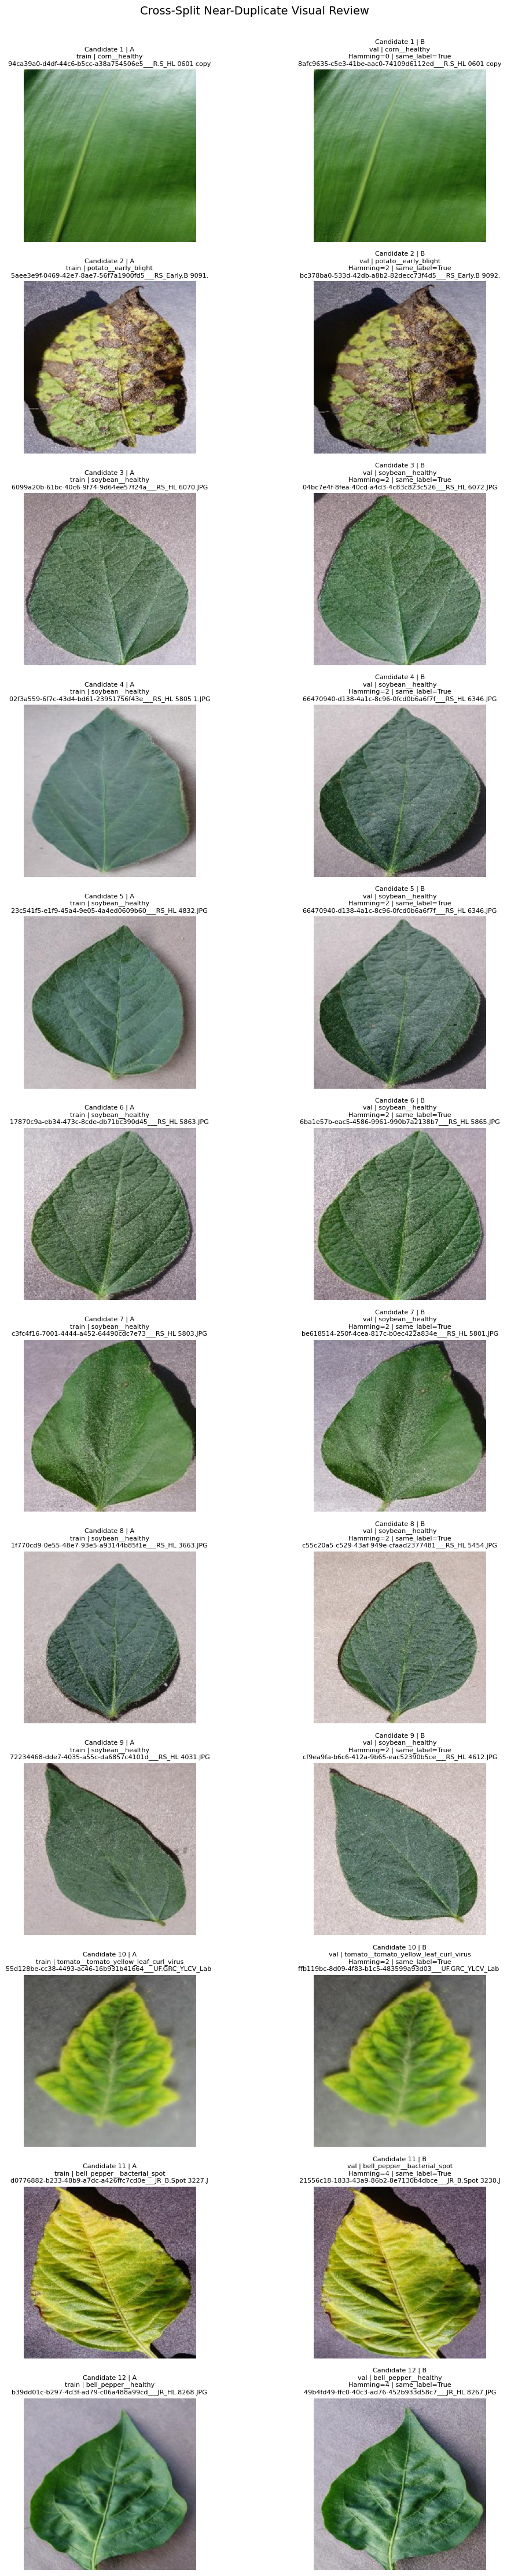

In [ ]:
def load_image_for_display(path, size=(256, 256)):
    try:
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            image.thumbnail(size)
            return image.copy()
    except Exception:
        return None


def make_candidate_review_pages(
    candidates,
    output_directory,
    rows_per_page=12,
    image_size=(220, 220)
):
    output_directory.mkdir(parents=True, exist_ok=True)
    
    candidates = candidates.sort_values(
        ["phash_hamming_distance", "candidate_id"]
    ).reset_index(drop=True)
    
    saved_files = []
    
    for start in range(0, len(candidates), rows_per_page):
        page_df = candidates.iloc[start:start + rows_per_page]
        n_rows = len(page_df)
        
        fig, axes = plt.subplots(
            n_rows,
            2,
            figsize=(12, max(4, n_rows * 3.7))
        )
        
        if n_rows == 1:
            axes = np.array([axes])
        
        for row_idx, (_, row) in enumerate(page_df.iterrows()):
            image_a = load_image_for_display(row["image_a_path"], image_size)
            image_b = load_image_for_display(row["image_b_path"], image_size)
            
            title_a = (
                f"Candidate {row['candidate_id']} | A\n"
                f"{row['split_a']} | {row['label_a']}\n"
                f"{Path(row['image_a_path']).name[:55]}"
            )
            
            title_b = (
                f"Candidate {row['candidate_id']} | B\n"
                f"{row['split_b']} | {row['label_b']}\n"
                f"Hamming={row['phash_hamming_distance']} | "
                f"same_label={row['same_label']}\n"
                f"{Path(row['image_b_path']).name[:55]}"
            )
            
            axes[row_idx, 0].imshow(image_a if image_a else np.zeros((20, 20, 3)))
            axes[row_idx, 0].set_title(title_a, fontsize=8)
            axes[row_idx, 0].axis("off")
            
            axes[row_idx, 1].imshow(image_b if image_b else np.zeros((20, 20, 3)))
            axes[row_idx, 1].set_title(title_b, fontsize=8)
            axes[row_idx, 1].axis("off")
        
        fig.suptitle(
            "Cross-Split Near-Duplicate Visual Review",
            fontsize=14,
            y=1.002
        )
        
        plt.tight_layout()
        
        page_number = (start // rows_per_page) + 1
        png_path = output_directory / f"near_duplicate_review_page_{page_number:02d}.png"
        pdf_path = output_directory / f"near_duplicate_review_page_{page_number:02d}.pdf"
        
        fig.savefig(png_path, dpi=200, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        
        saved_files.extend([png_path, pdf_path])
    
    return saved_files


REVIEW_FIG_DIR = FIG_DIR / "near_duplicate_review"

review_files = make_candidate_review_pages(
    candidates=cross_split_review_df,
    output_directory=REVIEW_FIG_DIR,
    rows_per_page=12
)

print(f"Created {len(review_files)} review files.")
print(REVIEW_FIG_DIR)

In [ ]:
reviewed_df = cross_split_review_df.copy()

reviewed_df["review_decision"] = "PENDING"
reviewed_df["review_reason"] = ""
reviewed_df["exclude_image_path"] = ""
reviewed_df["reviewer"] = "research_team"
reviewed_df["review_date"] = "2026-08-12"

display(
    reviewed_df[
        [
            "candidate_id",
            "phash_hamming_distance",
            "label_a",
            "label_b",
            "image_a_path",
            "image_b_path",
            "review_decision"
        ]
    ].head(20)
)

In [ ]:
# -------------------------------------------------------
# Manual near-duplicate decisions after visual inspection
# -------------------------------------------------------
# Candidate IDs are 1 through 136.
#
# CONFIRMED_LEAKAGE:
# Same leaf, same lesion geometry, same capture, or same image
# across train and original held-out validation.
#
# NOT_LEAKAGE:
# Clearly different leaves/captures.
#
# UNCERTAIN:
# Cannot confidently determine whether source leaf/capture is same.
# This is acceptable; the pair is retained and documented.

confirmed_ids = [
    # Example only: add IDs after visual confirmation.
    # 1,
]

not_leakage_ids = [
    # Add visually confirmed different-leaf IDs here.
]

uncertain_ids = [
    # TEMPORARY START: place every unreviewed ID here.
    # As you inspect a candidate, move its ID into confirmed_ids
    # or not_leakage_ids.
    *range(1, 137)
]

# Remove IDs placed in confirmed_ids or not_leakage_ids from uncertain_ids.
uncertain_ids = sorted(
    set(uncertain_ids) - set(confirmed_ids) - set(not_leakage_ids)
)

all_candidate_ids = set(reviewed_df["candidate_id"].tolist())
assigned_ids = (
    set(confirmed_ids) |
    set(not_leakage_ids) |
    set(uncertain_ids)
)

assert assigned_ids == all_candidate_ids, (
    "Every candidate ID must be assigned exactly once.\n"
    f"Missing: {sorted(all_candidate_ids - assigned_ids)}\n"
    f"Unknown: {sorted(assigned_ids - all_candidate_ids)}"
)

assert not (set(confirmed_ids) & set(not_leakage_ids))
assert not (set(confirmed_ids) & set(uncertain_ids))
assert not (set(not_leakage_ids) & set(uncertain_ids))

# Assign decisions
reviewed_df["review_decision"] = "PENDING"
reviewed_df["review_reason"] = ""
reviewed_df["exclude_image_path"] = ""
reviewed_df["reviewer"] = "research_team"
reviewed_df["review_date"] = "2026-08-12"

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(confirmed_ids),
    "review_decision"
] = "CONFIRMED_LEAKAGE"

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(not_leakage_ids),
    "review_decision"
] = "NOT_LEAKAGE"

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(uncertain_ids),
    "review_decision"
] = "UNCERTAIN"

# Exclude only the held-out/val side of confirmed leakage pairs.
reviewed_df.loc[
    reviewed_df["candidate_id"].isin(confirmed_ids),
    "exclude_image_path"
] = reviewed_df.loc[
    reviewed_df["candidate_id"].isin(confirmed_ids),
    "image_b_path"
]

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(confirmed_ids),
    "review_reason"
] = (
    "Confirmed same leaf/image or near-identical capture across "
    "original train and held-out partition"
)

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(not_leakage_ids),
    "review_reason"
] = "Different leaf/capture after visual review"

reviewed_df.loc[
    reviewed_df["candidate_id"].isin(uncertain_ids),
    "review_reason"
] = (
    "Could not confidently verify same source leaf/capture; "
    "retained and documented"
)

COMPLETED_REVIEW_PATH = (
    TABLE_DIR / "near_duplicate_review_decisions_completed.csv"
)

reviewed_df.to_csv(COMPLETED_REVIEW_PATH, index=False)

print("Confirmed leakage:", len(confirmed_ids))
print("Not leakage:", len(not_leakage_ids))
print("Uncertain:", len(uncertain_ids))
print("Pending:", (reviewed_df["review_decision"] == "PENDING").sum())
print("Saved:", COMPLETED_REVIEW_PATH)

display(
    reviewed_df["review_decision"]
    .value_counts()
    .rename_axis("decision")
    .reset_index(name="candidate_pairs")
)

## Manual review instructions

Open the `near_duplicate_review` figures.

For every candidate pair, choose one decision:

- `CONFIRMED_LEAKAGE`  
  The images are visually the same image, same leaf, or essentially the same capture; exclude the **validation/original held-out** image.

- `NOT_LEAKAGE`  
  The leaves are different examples, even if they are visually similar.

- `UNCERTAIN`  
  The pair cannot be confidently judged. Do not automatically remove it; document it.

### Conservative rule

Only use `CONFIRMED_LEAKAGE` when the candidate represents the same image, same leaf, or an almost identical capture across the original train and validation folders.

For confirmed leakage:
- Keep the original `train` image.
- Put the original `val` image path in `exclude_image_path`.
- Add a concise explanation in `review_reason`.

Example:

| review_decision | review_reason | exclude_image_path |
|---|---|---|
| CONFIRMED_LEAKAGE | Same leaf and lesion arrangement; only minor crop/encoding difference | `/kaggle/input/.../val/...JPG` |
| NOT_LEAKAGE | Different leaf shape and lesion distribution | leave empty |
| UNCERTAIN | Similar crop and orientation but insufficient evidence | leave empty |

In [ ]:
REVIEWED_DECISIONS_PATH = (
    TABLE_DIR / "near_duplicate_review_decisions_completed.csv"
)

assert REVIEWED_DECISIONS_PATH.exists(), (
    f"Completed review file not found: {REVIEWED_DECISIONS_PATH}"
)

reviewed_df = pd.read_csv(REVIEWED_DECISIONS_PATH)

reviewed_df["review_decision"] = (
    reviewed_df["review_decision"]
    .fillna("PENDING")
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Reloaded decisions:")
display(
    reviewed_df["review_decision"]
    .value_counts(dropna=False)
    .rename_axis("decision")
    .reset_index(name="candidate_pairs")
)

In [ ]:
pending_count = (
    reviewed_df["review_decision"] == "PENDING"
).sum()

if pending_count > 0:
    raise RuntimeError(
        f"{pending_count} near-duplicate candidates are still marked PENDING.\n"
        "Review the candidate figures and update near_duplicate_review_decisions.csv "
        "before locking the splits."
    )

print("All cross-split near-duplicate candidates have review decisions.")

In [ ]:
print(reviewed_df["review_decision"].value_counts(dropna=False))

pending_ids = reviewed_df.loc[
    reviewed_df["review_decision"] == "PENDING",
    "candidate_id"
].tolist()

print("Pending candidate IDs:", pending_ids)

In [ ]:
confirmed_df = reviewed_df[
    reviewed_df["review_decision"] == "CONFIRMED_LEAKAGE"
].copy()

print("Confirmed cross-split leakage pairs:", len(confirmed_df))

if len(confirmed_df) > 0:
    required_exclusions = confirmed_df["exclude_image_path"].fillna("").str.strip()
    
    assert (required_exclusions != "").all(), (
        "Every CONFIRMED_LEAKAGE row must specify exclude_image_path."
    )
    
    train_paths = set(
        master_df.loc[master_df["split"] == "train", "image_path"]
    )
    
    val_paths = set(
        master_df.loc[master_df["split"] == "val", "image_path"]
    )
    
    excluded_paths = set(required_exclusions)
    
    assert excluded_paths.issubset(val_paths), (
        "For confirmed leakage, exclude only original validation/held-out images. "
        "Keep original training images."
    )
    
    assert excluded_paths.isdisjoint(train_paths), (
        "A training image was selected for exclusion. Keep training copies and "
        "exclude only original validation copies."
    )
    
    display(
        confirmed_df[
            [
                "candidate_id",
                "phash_hamming_distance",
                "label_a",
                "label_b",
                "review_reason",
                "exclude_image_path"
            ]
        ]
    )
else:
    excluded_paths = set()
    print("No additional near-duplicate leakage exclusions were confirmed.")

In [ ]:
locked_df = master_df.copy()

locked_df["exclude_near_duplicate_leakage"] = (
    locked_df["image_path"].isin(excluded_paths)
).astype(int)

locked_df["dataset_status"] = np.where(
    locked_df["exclude_near_duplicate_leakage"] == 1,
    "excluded_confirmed_near_duplicate",
    "retained"
)

final_master_df = locked_df[
    locked_df["dataset_status"] == "retained"
].copy()

assert final_master_df["is_corrupt"].sum() == 0
assert final_master_df["label"].nunique() == 20

locked_manifest_path = MANIFEST_DIR / "plantvillage_master_manifest_locked.csv"
excluded_near_path = TABLE_DIR / "excluded_confirmed_near_duplicate_leakage.csv"

locked_df.to_csv(locked_manifest_path, index=False)

locked_df[
    locked_df["exclude_near_duplicate_leakage"] == 1
].to_csv(excluded_near_path, index=False)

print("Original clean dataset:", len(master_df))
print("Additional confirmed near-duplicate exclusions:", len(excluded_paths))
print("Final locked dataset:", len(final_master_df))
print("Locked manifest saved to:")
print(locked_manifest_path)

In [ ]:
SOYBEAN_LABEL = "soybean__healthy"

main19_df = final_master_df[
    final_master_df["label"] != SOYBEAN_LABEL
].copy()

aux20_df = final_master_df.copy()

assert main19_df["label"].nunique() == 19
assert aux20_df["label"].nunique() == 20

print("Main 19-class images:", len(main19_df))
print("Main 19-class labels:", main19_df["label"].nunique())

print("\nAuxiliary 20-class images:", len(aux20_df))
print("Auxiliary 20-class labels:", aux20_df["label"].nunique())

In [ ]:
CALIBRATION_FRACTION = 0.15
RANDOM_SEED = 7

def create_locked_splits(task_df, task_name):
    original_train = task_df[
        task_df["split"] == "train"
    ].copy()

    original_test = task_df[
        task_df["split"] == "val"
    ].copy()

    train_records, calibration_records = train_test_split(
        original_train,
        test_size=CALIBRATION_FRACTION,
        random_state=RANDOM_SEED,
        stratify=original_train["label"]
    )

    train_records = train_records.copy()
    calibration_records = calibration_records.copy()
    original_test = original_test.copy()

    train_records["final_split"] = "train"
    calibration_records["final_split"] = "calibration"
    original_test["final_split"] = "internal_test"

    result = pd.concat(
        [train_records, calibration_records, original_test],
        ignore_index=True
    )

    assert len(result) == len(task_df)
    assert result["final_split"].value_counts().sum() == len(task_df)

    print(f"\n{task_name}")
    print("Train:", (result["final_split"] == "train").sum())
    print("Calibration:", (result["final_split"] == "calibration").sum())
    print("Internal test:", (result["final_split"] == "internal_test").sum())

    return result


main19_split_df = create_locked_splits(main19_df, "Main 19-class task")
aux20_split_df = create_locked_splits(aux20_df, "Auxiliary 20-class task")

In [ ]:
def split_summary(split_df, task_name):
    summary = (
        split_df
        .groupby(["label", "crop", "disease", "final_split"], as_index=False)
        .size()
        .rename(columns={"size": "images"})
    )

    pivot = (
        summary
        .pivot_table(
            index=["label", "crop", "disease"],
            columns="final_split",
            values="images",
            fill_value=0
        )
        .reset_index()
    )

    for column in ["train", "calibration", "internal_test"]:
        if column not in pivot.columns:
            pivot[column] = 0

    pivot["total"] = (
        pivot["train"] +
        pivot["calibration"] +
        pivot["internal_test"]
    )

    assert (pivot["train"] > 0).all(), f"{task_name}: missing training class."
    assert (pivot["calibration"] > 0).all(), f"{task_name}: missing calibration class."
    assert (pivot["internal_test"] > 0).all(), f"{task_name}: missing test class."

    return pivot.sort_values("total", ascending=False)


main19_summary = split_summary(main19_split_df, "Main19")
aux20_summary = split_summary(aux20_split_df, "Aux20")

print("Main19 split summary:")
display(main19_summary)

print("\nAux20 split summary:")
display(aux20_summary)

In [ ]:
def export_task_splits(split_df, task_name):
    task_dir = MANIFEST_DIR / task_name
    task_dir.mkdir(parents=True, exist_ok=True)

    file_map = {
        "train": task_dir / f"{task_name}_train.csv",
        "calibration": task_dir / f"{task_name}_calibration.csv",
        "internal_test": task_dir / f"{task_name}_internal_test.csv"
    }

    for split_name, output_path in file_map.items():
        split_records = split_df[
            split_df["final_split"] == split_name
        ].copy()

        split_records.to_csv(output_path, index=False)

        print(
            f"{task_name} | {split_name}: "
            f"{len(split_records)} images -> {output_path.name}"
        )

    return file_map


main19_files = export_task_splits(main19_split_df, "main19")
aux20_files = export_task_splits(aux20_split_df, "aux20")

In [ ]:
def save_class_mapping(split_df, task_name):
    labels = sorted(split_df["label"].unique())
    class_to_index = {label: index for index, label in enumerate(labels)}
    index_to_class = {str(index): label for label, index in class_to_index.items()}

    class_to_index_path = METADATA_DIR / f"class_to_index_{task_name}.json"
    index_to_class_path = METADATA_DIR / f"index_to_class_{task_name}.json"

    with open(class_to_index_path, "w") as file:
        json.dump(class_to_index, file, indent=2)

    with open(index_to_class_path, "w") as file:
        json.dump(index_to_class, file, indent=2)

    return class_to_index, class_to_index_path, index_to_class_path


main19_class_to_index, main19_mapping_path, _ = save_class_mapping(
    main19_split_df,
    "main19"
)

aux20_class_to_index, aux20_mapping_path, _ = save_class_mapping(
    aux20_split_df,
    "aux20"
)

print("Main19 classes:", len(main19_class_to_index))
print("Aux20 classes:", len(aux20_class_to_index))

print("\nMain19 mapping:")
print(main19_mapping_path)

print("\nAux20 mapping:")
print(aux20_mapping_path)

In [ ]:
main19_summary_path = TABLE_DIR / "split_summary_main19_locked.csv"
aux20_summary_path = TABLE_DIR / "split_summary_aux20_locked.csv"

main19_summary.to_csv(main19_summary_path, index=False)
aux20_summary.to_csv(aux20_summary_path, index=False)

overall_split_summary = pd.DataFrame([
    {
        "task": "main19",
        "classes": main19_split_df["label"].nunique(),
        "train_images": int((main19_split_df["final_split"] == "train").sum()),
        "calibration_images": int((main19_split_df["final_split"] == "calibration").sum()),
        "internal_test_images": int((main19_split_df["final_split"] == "internal_test").sum()),
        "total_images": len(main19_split_df)
    },
    {
        "task": "aux20",
        "classes": aux20_split_df["label"].nunique(),
        "train_images": int((aux20_split_df["final_split"] == "train").sum()),
        "calibration_images": int((aux20_split_df["final_split"] == "calibration").sum()),
        "internal_test_images": int((aux20_split_df["final_split"] == "internal_test").sum()),
        "total_images": len(aux20_split_df)
    }
])

overall_summary_path = TABLE_DIR / "split_summary_locked.csv"
overall_split_summary.to_csv(overall_summary_path, index=False)

display(overall_split_summary)

print("\nSaved:")
print(main19_summary_path)
print(aux20_summary_path)
print(overall_summary_path)

In [ ]:
plot_df = (
    main19_split_df
    .groupby(["label", "final_split"])
    .size()
    .reset_index(name="images")
)

pivot_plot = (
    plot_df
    .pivot(index="label", columns="final_split", values="images")
    .fillna(0)
)

plot_order = pivot_plot.sum(axis=1).sort_values().index
pivot_plot = pivot_plot.loc[plot_order]

colors = {
    "train": "#4C78A8",
    "calibration": "#F58518",
    "internal_test": "#54A24B"
}

ax = pivot_plot[
    ["train", "calibration", "internal_test"]
].plot(
    kind="barh",
    stacked=True,
    figsize=(13, 9),
    color=[colors["train"], colors["calibration"], colors["internal_test"]],
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "Locked Data Partition for Main 19-Class Disease Classification",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Number of Images")
ax.set_ylabel("Crop-Disease Label")
ax.legend(
    title="Final split",
    loc="lower right"
)

plt.tight_layout()

split_plot_png = FIG_DIR / "fig_01_main19_locked_split_distribution.png"
split_plot_pdf = FIG_DIR / "fig_01_main19_locked_split_distribution.pdf"

plt.savefig(split_plot_png, dpi=300, bbox_inches="tight")
plt.savefig(split_plot_pdf, bbox_inches="tight")
plt.show()

print("Saved:")
print(split_plot_png)
print(split_plot_pdf)

In [ ]:
protocol = {
    "dataset_name": "PlantVillage selected crop subset",
    "dataset_root": str(PLANTVILLAGE_ROOT),
    "master_manifest_source": str(CLEAN_MANIFEST_PATH),
    "locked_master_manifest": str(locked_manifest_path),
    "selected_crops": [
        "bell_pepper",
        "corn",
        "potato",
        "soybean",
        "tomato"
    ],
    "main_task": {
        "name": "main19_multi_crop_disease_classification",
        "classes": 19,
        "excluded_label": "soybean__healthy",
        "purpose": "Headline disease classification experiments"
    },
    "auxiliary_task": {
        "name": "aux20_full_selected_subset_classification",
        "classes": 20,
        "includes_soybean_healthy": True,
        "purpose": "Secondary supplementary experiment"
    },
    "original_train_role": "Development pool only",
    "calibration_fraction_from_original_train": CALIBRATION_FRACTION,
    "original_val_role": "Untouched internal test set",
    "random_seed": RANDOM_SEED,
    "exact_duplicates_removed_previously": 5,
    "confirmed_near_duplicate_exclusions": len(excluded_paths),
    "final_locked_images": int(len(final_master_df)),
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

protocol_path = METADATA_DIR / "data_protocol.json"

with open(protocol_path, "w") as file:
    json.dump(protocol, file, indent=2)

print(json.dumps(protocol, indent=2))
print("\nSaved:")
print(protocol_path)

In [ ]:
def run_integrity_checks(split_df, task_name, expected_classes):
    assert split_df["label"].nunique() == expected_classes
    assert split_df["image_path"].nunique() == len(split_df)
    assert split_df["is_corrupt"].sum() == 0

    split_sets = {
        split_name: set(
            split_df.loc[
                split_df["final_split"] == split_name,
                "image_path"
            ]
        )
        for split_name in ["train", "calibration", "internal_test"]
    }

    assert split_sets["train"].isdisjoint(split_sets["calibration"])
    assert split_sets["train"].isdisjoint(split_sets["internal_test"])
    assert split_sets["calibration"].isdisjoint(split_sets["internal_test"])

    train_labels = set(
        split_df.loc[
            split_df["final_split"] == "train",
            "label"
        ]
    )

    calibration_labels = set(
        split_df.loc[
            split_df["final_split"] == "calibration",
            "label"
        ]
    )

    test_labels = set(
        split_df.loc[
            split_df["final_split"] == "internal_test",
            "label"
        ]
    )

    assert train_labels == calibration_labels == test_labels

    print(f"PASS: {task_name}")
    print("Images:", len(split_df))
    print("Classes:", split_df["label"].nunique())
    print(
        split_df["final_split"]
        .value_counts()
        .sort_index()
        .to_dict()
    )


run_integrity_checks(main19_split_df, "Main19", expected_classes=19)
run_integrity_checks(aux20_split_df, "Aux20", expected_classes=20)

In [ ]:
print("=" * 70)
print("NOTEBOOK 02 COMPLETED")
print("=" * 70)

print("\nMain task:")
print("  Task: 19-class multi-crop disease classification")
print("  Soybean healthy excluded from headline experiments")
print("  Training split:", len(main19_split_df[main19_split_df["final_split"] == "train"]))
print("  Calibration split:", len(main19_split_df[main19_split_df["final_split"] == "calibration"]))
print("  Internal test split:", len(main19_split_df[main19_split_df["final_split"] == "internal_test"]))

print("\nAuxiliary task:")
print("  Task: 20-class selected-subset classification")
print("  Includes soybean healthy")

print("\nImportant locked rule:")
print("  Never use internal_test for model selection, early stopping,")
print("  augmentation choices, threshold selection, or temperature scaling.")

print("\nKey output directory:")
print(OUTPUT_DIR)